# 04 · Entrenamiento del predictor del día siguiente

**Requiere TensorFlow** (Google Colab, o un entorno local con
`requirements.txt` instalado — ver README, sección "Entorno").

Dos pasos, con separacion temporal estricta. Primero se selecciona la
arquitectura por el ERROR EN VALIDACIÓN (nunca en test); despues, con esa
arquitectura ya fijada, se comparan los generadores en el test final.

1. **Elegir arquitectura** (enunciado, paso 4): con SOLO la ventana real
   disponible para entrenar (sin ningún día sintético), se comparan
   baseline / lineal / densa / CNN / CNN profunda / RNN / RNN profunda —
   misma comparación que `Taller_con_Datos_SP500_promedio.ipynb`, pero
   con nuestros bancos y 2 canales por banco (retorno + volatilidad
   realizada). La tabla generada `04_comparacion_arquitecturas.csv`
   incluye metricas de validacion (`split=validation`).
2. **Rejilla años de sintéticos × generador**: con la arquitectura
   ganadora, se entrena una versión por cada combinación
   (`SYNTH_DEPTH_YEARS_GRID` años de backfill sintético añadidos) ×
   (generador que rellenó esos años), evaluando siempre en el MISMO test
   real (`REAL_TEST_HOLDOUT_START_DATE` en adelante). Ese test no se usa
   para decidir la arquitectura.

**Sobre las fechas** (ver `src/config.py`): la ventana real de
`REAL_INTRADAY_YEARS` (~2 años) se reparte en train/val/test — val y test
se comen la mitad, así que lo que queda para entrenar "solo con reales"
es solo ~1 año (`synth_years=0`). A partir de ahí, `synth_years` cuenta
hacia atrás desde `REAL_INTRADAY_START_DATE` cuánta historia con
volatilidad SINTÉTICA se añade — el final del entrenamiento
(`VAL_START_DATE`) es siempre el mismo, no cambia con la profundidad.

**Sobre la métrica — MAE como *loss*, no solo como número final**: la
diapositiva de teoría del taller ("REAL PROBLEM",
`2026_Taller_Generativos.pdf` pág. 11-12) especifica **"Learning:
minimize MAE"** para el problema real que motiva el taller, y reporta el
error en las unidades del target (Kelvin) — la ventaja de MAE frente a
MSE, que queda en unidades al cuadrado. El retorno diario es igual de
heavy-tailed que ese problema (ver notebook 02: la Gaussiana no
reproduce el pico leptocúrtico de los datos reales), así que entrenar
con MSE dejaría que los pocos días de retorno extremo dominen el
gradiente. Por eso aquí se entrena con `loss='mae'` (parámetro de
`build_predictor_*`, ver `LOSS_FUNCTION` más abajo). Se reportan MAE,
MSE y precisión direccional para cada modelo.

**Sobre la convergencia**: `EarlyStopping` con `patience` alto (no unas
pocas epochs) — el criterio de parada exige que `val_loss` lleve
`EARLY_STOPPING_PATIENCE` epochs SEGUIDAS sin mejorar, así que cuando un
entrenamiento para, la curva de loss ya lleva un tramo largo y plano:
es la evidencia visual de convergencia que pide el enunciado, no solo
"dejó de mejorar hace poco". Además, `ReduceLROnPlateau` baja el
learning rate cuando `val_loss` se estanca, para intentar que el modelo
siga afinando con pasos más pequeños antes de parar.


**Sobre reproducibilidad**: se fija `RANDOM_STATE` y se reinicia antes de
cada entrenamiento. Asi, al comparar generadores/profundidades, todos los
modelos parten de la misma inicializacion aleatoria y las diferencias se
deben al dataset usado, no al azar del entrenamiento.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

# Recarga automatica de src/ al editarlo: sin esto, si se edita un modulo
# de src/ con el kernel ya arrancado, Jupyter sigue usando la version que
# importo la primera vez (y aparecen errores tipo "unexpected keyword
# argument" con codigo que en disco si es correcto).
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except NameError:
    pass  # ejecutandose fuera de IPython/Jupyter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, modelos, plotting as pl, train_utils as tu

# EPOCHS_* son un techo de seguridad, no el nº de epochs que se entrena
# realmente: tanto run_architecture_comparison como run_depth_grid paran
# antes vía EarlyStopping (ver arriba). El techo se deja holgado para que
# sea EarlyStopping, no el techo, quien decida cuándo parar.
EPOCHS_ARQUITECTURA = 300
EPOCHS_REJILLA = 500
BATCH_SIZE = 64
EARLY_STOPPING_PATIENCE = 100
LOSS_FUNCTION = "mae"
RANDOM_STATE = 42

## 1. Cargar los 4 datasets de 30 años (notebook 03)

In [2]:
datasets_by_generator = {}
for name in ["noise", "gaussian", "rbig", "gan"]:
    path = config.INTERIM_DIR / f"dataset_{name}.npz"
    if not path.exists():
        continue
    npz = np.load(path, allow_pickle=True)
    idx = pd.DatetimeIndex(npz["idx"])
    datasets_by_generator[name] = (npz["X"], npz["Y"], idx, npz["is_synthetic"])
    print(f"{name}: X {npz['X'].shape}  Y {npz['Y'].shape}")

N_CHANNELS = datasets_by_generator[next(iter(datasets_by_generator))][0].shape[-1]  # 2 * N_PREDICTOR_TICKERS
assert N_CHANNELS == 2 * config.N_PREDICTOR_TICKERS

noise: X (7326, 60, 50)  Y (7326, 25)
gaussian: X (7326, 60, 50)  Y (7326, 25)
rbig: X (7326, 60, 50)  Y (7326, 25)
gan: X (7326, 60, 50)  Y (7326, 25)


## 2. Separar validación y test (reales, jamás usados por los generadores)

In [3]:
def val_test_split(X, Y, idx):
    val_mask = (idx >= pd.Timestamp(config.VAL_START_DATE)) & (idx < pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE))
    test_mask = idx >= pd.Timestamp(config.REAL_TEST_HOLDOUT_START_DATE)
    return (X[val_mask], Y[val_mask]), (X[test_mask], Y[test_mask])

ref_name = next(iter(datasets_by_generator))
(X_val, Y_val), (X_test, Y_test) = val_test_split(*datasets_by_generator[ref_name][:3])
print(f"val: {X_val.shape}   test: {X_test.shape}")

val: (126, 60, 50)   test: (122, 60, 50)


## 3. Elegir arquitectura, usando SOLO la ventana real disponible

`synth_years=0`: ni un solo día con volatilidad sintética todavía (ver
`train_utils.slice_by_depth`) — solo el ~1 año real que queda entre
`REAL_INTRADAY_START_DATE` y `VAL_START_DATE`.

In [4]:
X_full, Y_full, idx_full, is_synth_full = datasets_by_generator[ref_name]
X_train_arch, Y_train_arch, _, _ = tu.slice_by_depth(
    X_full, Y_full, idx_full, synth_years=0,
    train_end=config.VAL_START_DATE, synth_anchor=config.REAL_INTRADAY_START_DATE,
    is_synthetic=is_synth_full,
)
print("train (arquitectura, solo reales):", X_train_arch.shape)

output_dim = config.N_PREDICTOR_TICKERS
window_x = config.WINDOW_X_DAYS

architectures = {
    "baseline": lambda: modelos.build_predictor_baseline(output_dim=output_dim),
    "linear": lambda: modelos.build_predictor_linear(),
    "dense": lambda: modelos.build_predictor_dense(
        window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), loss=LOSS_FUNCTION
    ),
    "cnn_1bloque": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64,), loss=LOSS_FUNCTION
    ),
    "cnn_3bloques": lambda: modelos.build_predictor_cnn(
        window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), loss=LOSS_FUNCTION
    ),
    "rnn_1capa": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64,), loss=LOSS_FUNCTION
    ),
    "rnn_2capas": lambda: modelos.build_predictor_rnn(
        window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), loss=LOSS_FUNCTION
    ),
}

arch_results, arch_histories = tu.run_architecture_comparison(
    architectures, X_train_arch, Y_train_arch, X_val, Y_val,
    epochs=EPOCHS_ARQUITECTURA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    random_state=RANDOM_STATE,
)
arch_results.to_csv(config.TABLES_DIR / "04_comparacion_arquitecturas.csv")
arch_results.sort_values("mae")

train (arquitectura, solo reales): (252, 60, 50)


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000241058A6CA0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


,split,fit_seconds,mse,mae,directional_accuracy
model,,,,,
rnn_2capas,validation,23.012416,0.000251,0.011515,0.513968
rnn_1capa,validation,12.356645,0.000251,0.011517,0.520317
cnn_3bloques,validation,9.003688,0.000252,0.011529,0.511429
cnn_1bloque,validation,7.511652,0.000254,0.011581,0.505079
dense,validation,7.041394,0.000264,0.012002,0.500952
linear,validation,0.064544,0.000442,0.016283,0.494286
baseline,validation,0.000000,0.000514,0.017142,0.463492


WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_loss_curvas_arquitecturas.png')

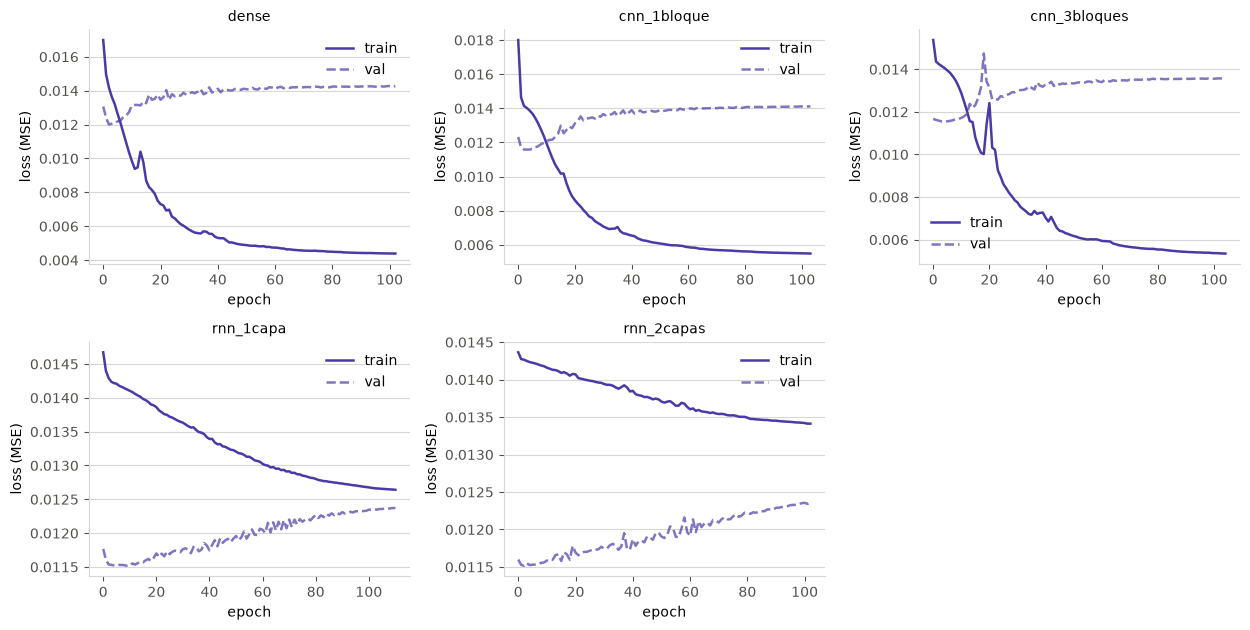

In [5]:
fig = pl.plot_loss_grid(arch_histories, ncols=3)
pl.savefig(fig, "04_loss_curvas_arquitecturas")

Se elige la arquitectura con menor MAE en **validación**. Las columnas
`mae`, `mse` y `directional_accuracy` de `arch_results` son de validacion
(`split=validation`); el test se reserva para la comparacion de generadores
del siguiente paso.

In [6]:
ARQUITECTURA_GANADORA = arch_results["mae"].idxmin()
mejor_direccional = arch_results["directional_accuracy"].idxmax()
print("Arquitectura elegida (menor MAE):", ARQUITECTURA_GANADORA)
if mejor_direccional != ARQUITECTURA_GANADORA:
    print(
        f"[AVISO] '{mejor_direccional}' tiene mejor precisión direccional "
        f"({arch_results.loc[mejor_direccional, 'directional_accuracy']:.3f} vs "
        f"{arch_results.loc[ARQUITECTURA_GANADORA, 'directional_accuracy']:.3f}) aunque peor MAE — "
        "vale la pena citar ambas arquitecturas en la presentación."
    )


def build_final_model():
    if ARQUITECTURA_GANADORA == "cnn_1bloque":
        return modelos.build_predictor_cnn(window_x, N_CHANNELS, output_dim, conv_filters=(64,), loss=LOSS_FUNCTION)
    if ARQUITECTURA_GANADORA == "cnn_3bloques":
        return modelos.build_predictor_cnn(
            window_x, N_CHANNELS, output_dim, conv_filters=(64, 128, 128), loss=LOSS_FUNCTION
        )
    if ARQUITECTURA_GANADORA == "rnn_1capa":
        return modelos.build_predictor_rnn(window_x, N_CHANNELS, output_dim, lstm_units=(64,), loss=LOSS_FUNCTION)
    if ARQUITECTURA_GANADORA == "rnn_2capas":
        return modelos.build_predictor_rnn(
            window_x, N_CHANNELS, output_dim, lstm_units=(64, 128), loss=LOSS_FUNCTION
        )
    if ARQUITECTURA_GANADORA == "dense":
        return modelos.build_predictor_dense(
            window_x, N_CHANNELS, output_dim, hidden_units=(128, 64), loss=LOSS_FUNCTION
        )
    raise ValueError(f"Arquitectura no keras seleccionada ({ARQUITECTURA_GANADORA}); revisar manualmente.")

Arquitectura elegida (menor MAE): rnn_2capas
[AVISO] 'rnn_1capa' tiene mejor precisión direccional (0.520 vs 0.514) aunque peor MAE — vale la pena citar ambas arquitecturas en la presentación.


## 4. Rejilla años de backfill sintético × generador

`synth_years=0` es idéntico para los 4 (sin sintéticos: fila
`solo_reales`, una sola vez); a partir de ahí cada generador aporta su
propio backfill y diverge. Se calcula también el desglose MAE/MSE/
precisión direccional POR BANCO (`ticker_names`), igual que la
comparación final de `Taller_con_Datos_SP500_promedio.ipynb`: una MAE
pooleada sobre los 25 bancos queda dominada por los de mayor volatilidad
(ver notebook 01, GBCI ~1.6x más volátil que JPM).

La función guarda checkpoints en `datos/interim` tras cada combinación. Si
el notebook se interrumpe, al reejecutarlo salta las combinaciones ya
terminadas y continua desde la primera pendiente.

In [7]:
results, histories, per_ticker = tu.run_depth_grid(
    build_final_model, datasets_by_generator, X_val, Y_val, X_test, Y_test,
    synth_years_grid=config.SYNTH_DEPTH_YEARS_GRID, train_end=config.VAL_START_DATE,
    synth_anchor=config.REAL_INTRADAY_START_DATE,
    epochs=EPOCHS_REJILLA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    random_state=RANDOM_STATE,
    ticker_names=config.PREDICTOR_TICKERS,
    checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad.csv",
    history_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad_histories.json",
    per_ticker_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_profundidad_por_banco.csv",
)
results.to_csv(config.TABLES_DIR / "04_resultados_rejilla_profundidad.csv")
results.sort_values(["generator", "synth_years"])

[depth] entrenando solo_reales, synth_years=0


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[depth] checkpoint guardado: 1 filas
[depth] entrenando noise, synth_years=7


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[depth] checkpoint guardado: 2 filas
[depth] entrenando gaussian, synth_years=7


...

c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[depth] checkpoint guardado: 16 filas
[depth] entrenando gan, synth_years=28


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[depth] checkpoint guardado: 17 filas


,generator,synth_years,n_train,pct_synth,mse,mae,directional_accuracy
1,gan,7,2013,0.874814,0.000253,0.011826,0.530164
5,gan,14,3774,0.933227,0.000253,0.011866,0.509508
9,gan,21,5537,0.954488,0.000251,0.011794,0.505574
13,gan,28,7078,0.964397,0.000250,0.011771,0.524262
2,gaussian,7,2013,0.874814,0.000256,0.011926,0.521311
6,gaussian,14,3774,0.933227,0.000253,0.011821,0.525574
10,gaussian,21,5537,0.954488,0.000252,0.011811,0.516721
14,gaussian,28,7078,0.964397,0.000253,0.011860,0.521639
3,noise,7,2013,0.874814,0.000254,0.011858,0.528852
7,noise,14,3774,0.933227,0.000254,0.011835,0.524590


WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_mae_vs_profundidad.png')

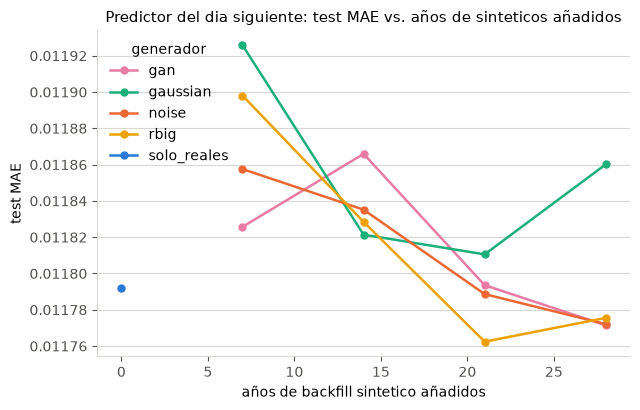

In [8]:
fig = pl.plot_depth_grid_results(results, metric="mae")
pl.savefig(fig, "04_mae_vs_profundidad")

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_mse_vs_profundidad.png')

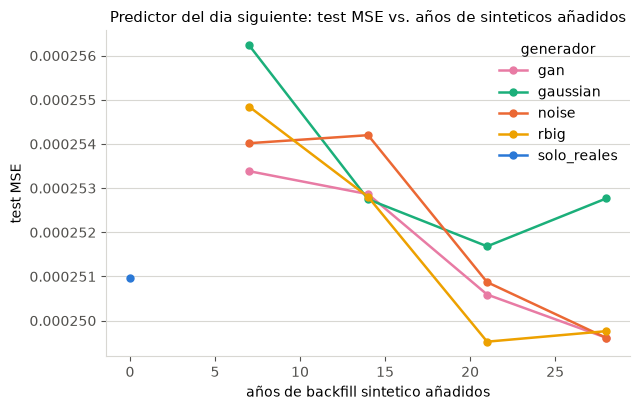

In [9]:
fig = pl.plot_depth_grid_results(results, metric="mse")
pl.savefig(fig, "04_mse_vs_profundidad")

WindowsPath('C:/Users/Natalia/workplace/Taller-B5-T1-Generativos/reports/figures/04_precision_direccional_vs_profundidad.png')

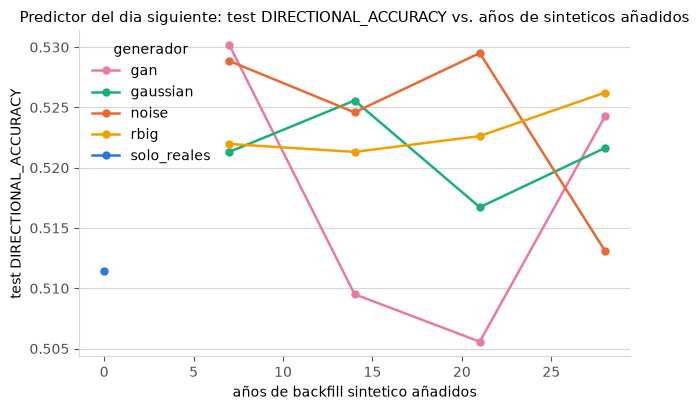

In [10]:
fig = pl.plot_depth_grid_results(results, metric="directional_accuracy")
pl.savefig(fig, "04_precision_direccional_vs_profundidad")

## 5. Rejilla por PORCENTAJE de datos sintéticos × generador

El paso 3 del enunciado pide "datasets que tengan distinto **porcentaje**
de datos sintéticos y reales", y el paso 5 pide ver "cómo meter más o
menos datos sintéticos modifica el comportamiento del modelo". La rejilla
de la sección anterior está expresada en **años** de historia recuperada
—que es la rejilla natural del problema financiero— pero traducida a
porcentaje cae en 0% y luego 87/93/95/96%: cuatro puntos amontonados en
el extremo alto, con todo el tramo 0-87% sin muestrear. Ahí no se puede
ver la forma de la curva.

Esta rejilla barre el eje de forma uniforme (`PCT_SYNTH_GRID`),
manteniendo **todas** las filas reales disponibles y añadiendo las
sintéticas más recientes que hagan falta para alcanzar cada proporción
(`train_utils.slice_by_pct`). El caso `pct=1.0` entrena **sin ninguna
fila real**: mide cuánta señal real hace falta como ancla.

Misma arquitectura ganadora, mismos pesos reinicializados, mismo test
real — lo único que cambia entre versiones es la composición del
entrenamiento. Aquí no se calcula desglose por banco porque no se usa en
las salidas de porcentaje; así evitamos predicciones y checkpoints
auxiliares innecesarios.

In [11]:
results_pct, histories_pct, per_ticker_pct = tu.run_pct_grid(
    build_final_model, datasets_by_generator, X_val, Y_val, X_test, Y_test,
    pct_grid=config.PCT_SYNTH_GRID, train_end=config.VAL_START_DATE,
    epochs=EPOCHS_REJILLA, batch_size=BATCH_SIZE, verbose=0,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    random_state=RANDOM_STATE,
    checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_porcentaje.csv",
    history_checkpoint_path=config.INTERIM_DIR / "04_checkpoint_rejilla_porcentaje_histories.json",
)
results_pct.to_csv(config.TABLES_DIR / "04_resultados_rejilla_porcentaje.csv")
results_pct.sort_values(["generator", "pct_objetivo"])

[pct] entrenando solo_reales, pct=0.0


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
[pct] checkpoint guardado: 1 filas
[pct] entrenando noise, pct=0.25


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[pct] checkpoint guardado: 2 filas
[pct] entrenando gaussian, pct=0.25


...

c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[pct] checkpoint guardado: 20 filas
[pct] entrenando gan, pct=1.0


c:\Users\Natalia\workplace\Taller-B5-T1-Generativos\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[pct] checkpoint guardado: 21 filas


,generator,pct_objetivo,n_train,pct_synth,mse,mae,directional_accuracy
1,gan,0.25,336,0.25,0.000258,0.011915,0.515410
5,gan,0.50,504,0.50,0.000250,0.011788,0.511148
9,gan,0.75,1008,0.75,0.000252,0.011824,0.485246
13,gan,0.90,2520,0.90,0.000251,0.011794,0.520000
17,gan,1.00,6826,1.00,0.000251,0.011790,0.491803
2,gaussian,0.25,336,0.25,0.000251,0.011760,0.516393
6,gaussian,0.50,504,0.50,0.000250,0.011780,0.515410
10,gaussian,0.75,1008,0.75,0.000252,0.011841,0.478361
14,gaussian,0.90,2520,0.90,0.000254,0.011847,0.511148
18,gaussian,1.00,6826,1.00,0.000250,0.011777,0.518361


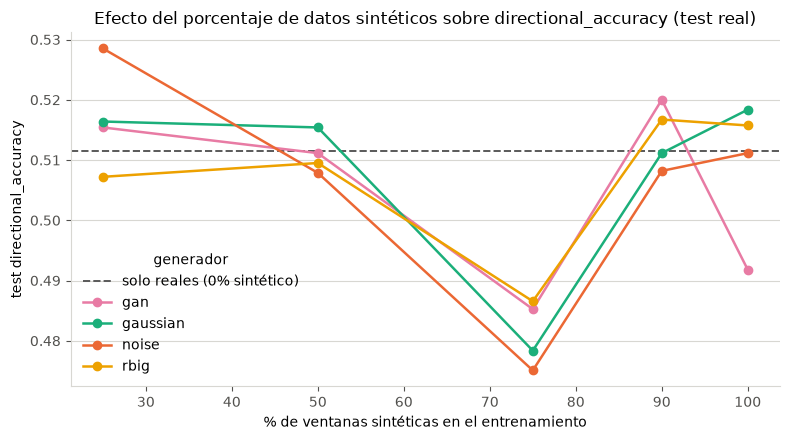

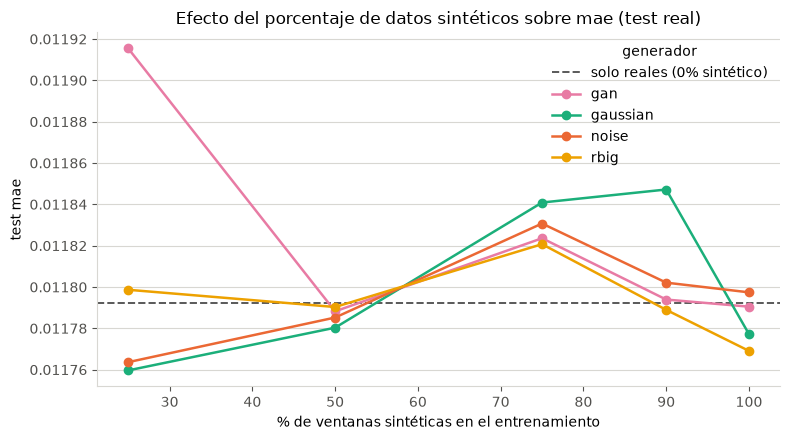

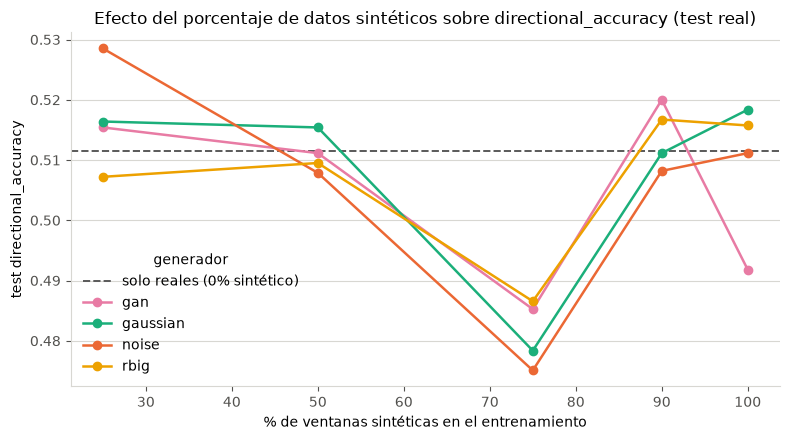

In [12]:
for metrica, nombre_fig in [
    ("mae", "04_mae_vs_porcentaje"),
    ("directional_accuracy", "04_precision_direccional_vs_porcentaje"),
]:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    solo_reales = results_pct[results_pct.generator == "solo_reales"]
    if not solo_reales.empty:
        ax.axhline(
            solo_reales[metrica].iloc[0], color="0.35", linestyle="--", linewidth=1.4,
            label="solo reales (0% sintético)",
        )
    for gen_name, sub in results_pct[results_pct.generator != "solo_reales"].groupby("generator"):
        sub = sub.sort_values("pct_synth")
        ax.plot(sub.pct_synth * 100, sub[metrica], marker="o", linewidth=1.8,
                color=pl.color_for(gen_name), label=gen_name)
    ax.set_xlabel("% de ventanas sintéticas en el entrenamiento")
    ax.set_ylabel(f"test {metrica}")
    ax.set_title(f"Efecto del porcentaje de datos sintéticos sobre {metrica} (test real)")
    ax.legend(frameon=False, title="generador")
    pl.style_axes(ax)
    fig.tight_layout()
    pl.savefig(fig, nombre_fig)

fig

## 6. Desglose por banco a máxima profundidad sintética

Gráfico de barras agrupado MAE por banco y generador (misma idea que el
bloque final de `Taller_con_Datos_SP500_promedio.ipynb`), en el punto de
mayor profundidad de la rejilla.

C:\Users\Natalia\AppData\Local\Temp\ipykernel_25192\2829106283.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


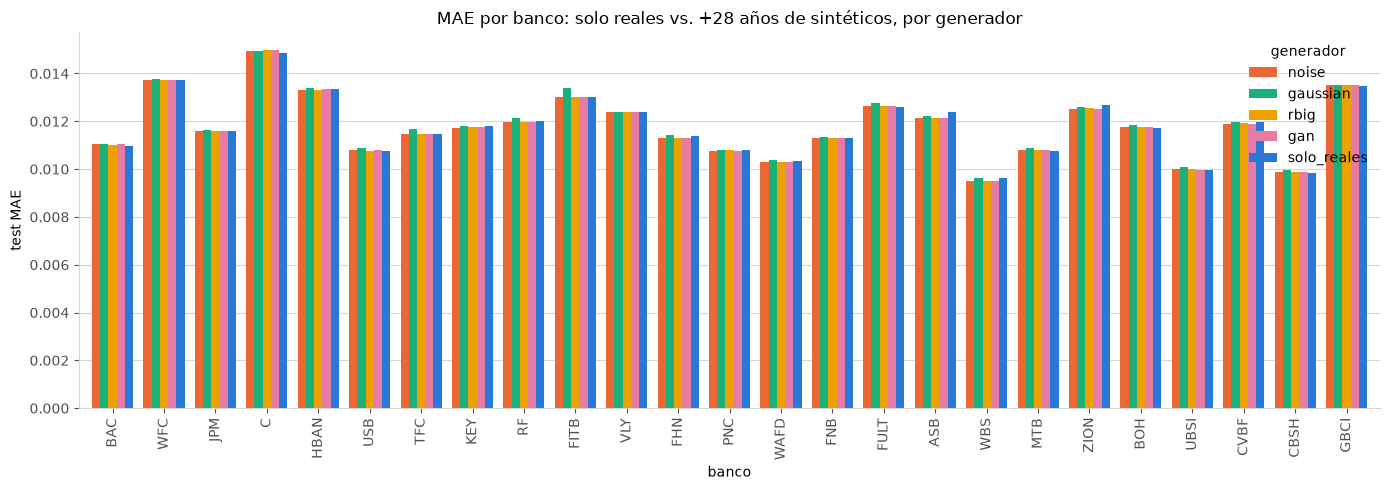

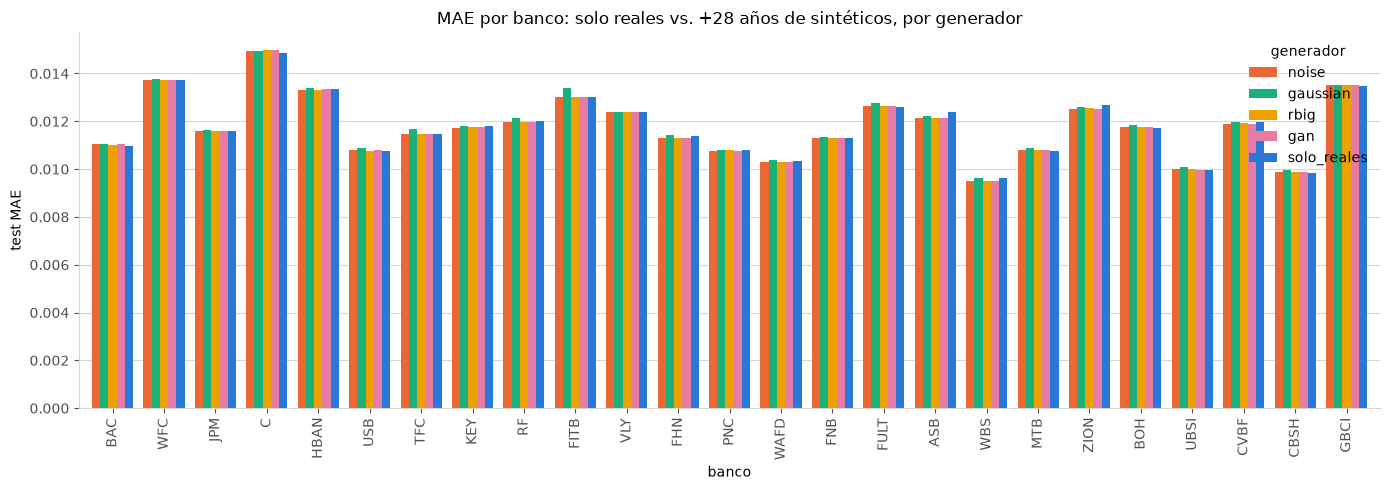

In [13]:
synth_years_max = config.SYNTH_DEPTH_YEARS_GRID[-1]
per_ticker_final = {
    gen_name: df for (gen_name, sy), df in per_ticker.items() if sy == synth_years_max
}
per_ticker_final["solo_reales"] = per_ticker[("solo_reales", config.SYNTH_DEPTH_YEARS_GRID[0])]

per_ticker_table = pd.concat(
    {name: df["mae"] for name, df in per_ticker_final.items()}, axis=1
)
per_ticker_table.to_csv(config.TABLES_DIR / "04_mae_por_banco.csv")

fig, ax = plt.subplots(figsize=(14, 5))
per_ticker_table.plot(
    kind="bar", ax=ax,
    color=[pl.color_for(c) for c in per_ticker_table.columns],
    width=0.8,
)
ax.set_ylabel("test MAE")
ax.set_xlabel("banco")
ax.set_title(f"MAE por banco: solo reales vs. +{synth_years_max} años de sintéticos, por generador")
ax.legend(frameon=False, title="generador")
pl.style_axes(ax)
fig.tight_layout()
pl.savefig(fig, "04_mae_por_banco")
fig

## 7. Curvas de loss de **todos** los entrenamientos

El enunciado exige, literalmente, "para **cada** entrenamiento, incluir
las curvas de loss donde se vea que el modelo ha convergido" — no una
muestra representativa. Así que aquí se vuelcan las tres tandas
completas: las 7 arquitecturas candidatas (sección 3), los
`4 × (len(SYNTH_DEPTH_YEARS_GRID)-1) + 1` de la rejilla por años y los
de la rejilla por porcentaje. Cada panel lleva el mismo criterio de
parada (`EarlyStopping` con paciencia alta), así que el tramo plano
final es la evidencia de convergencia que se pide.

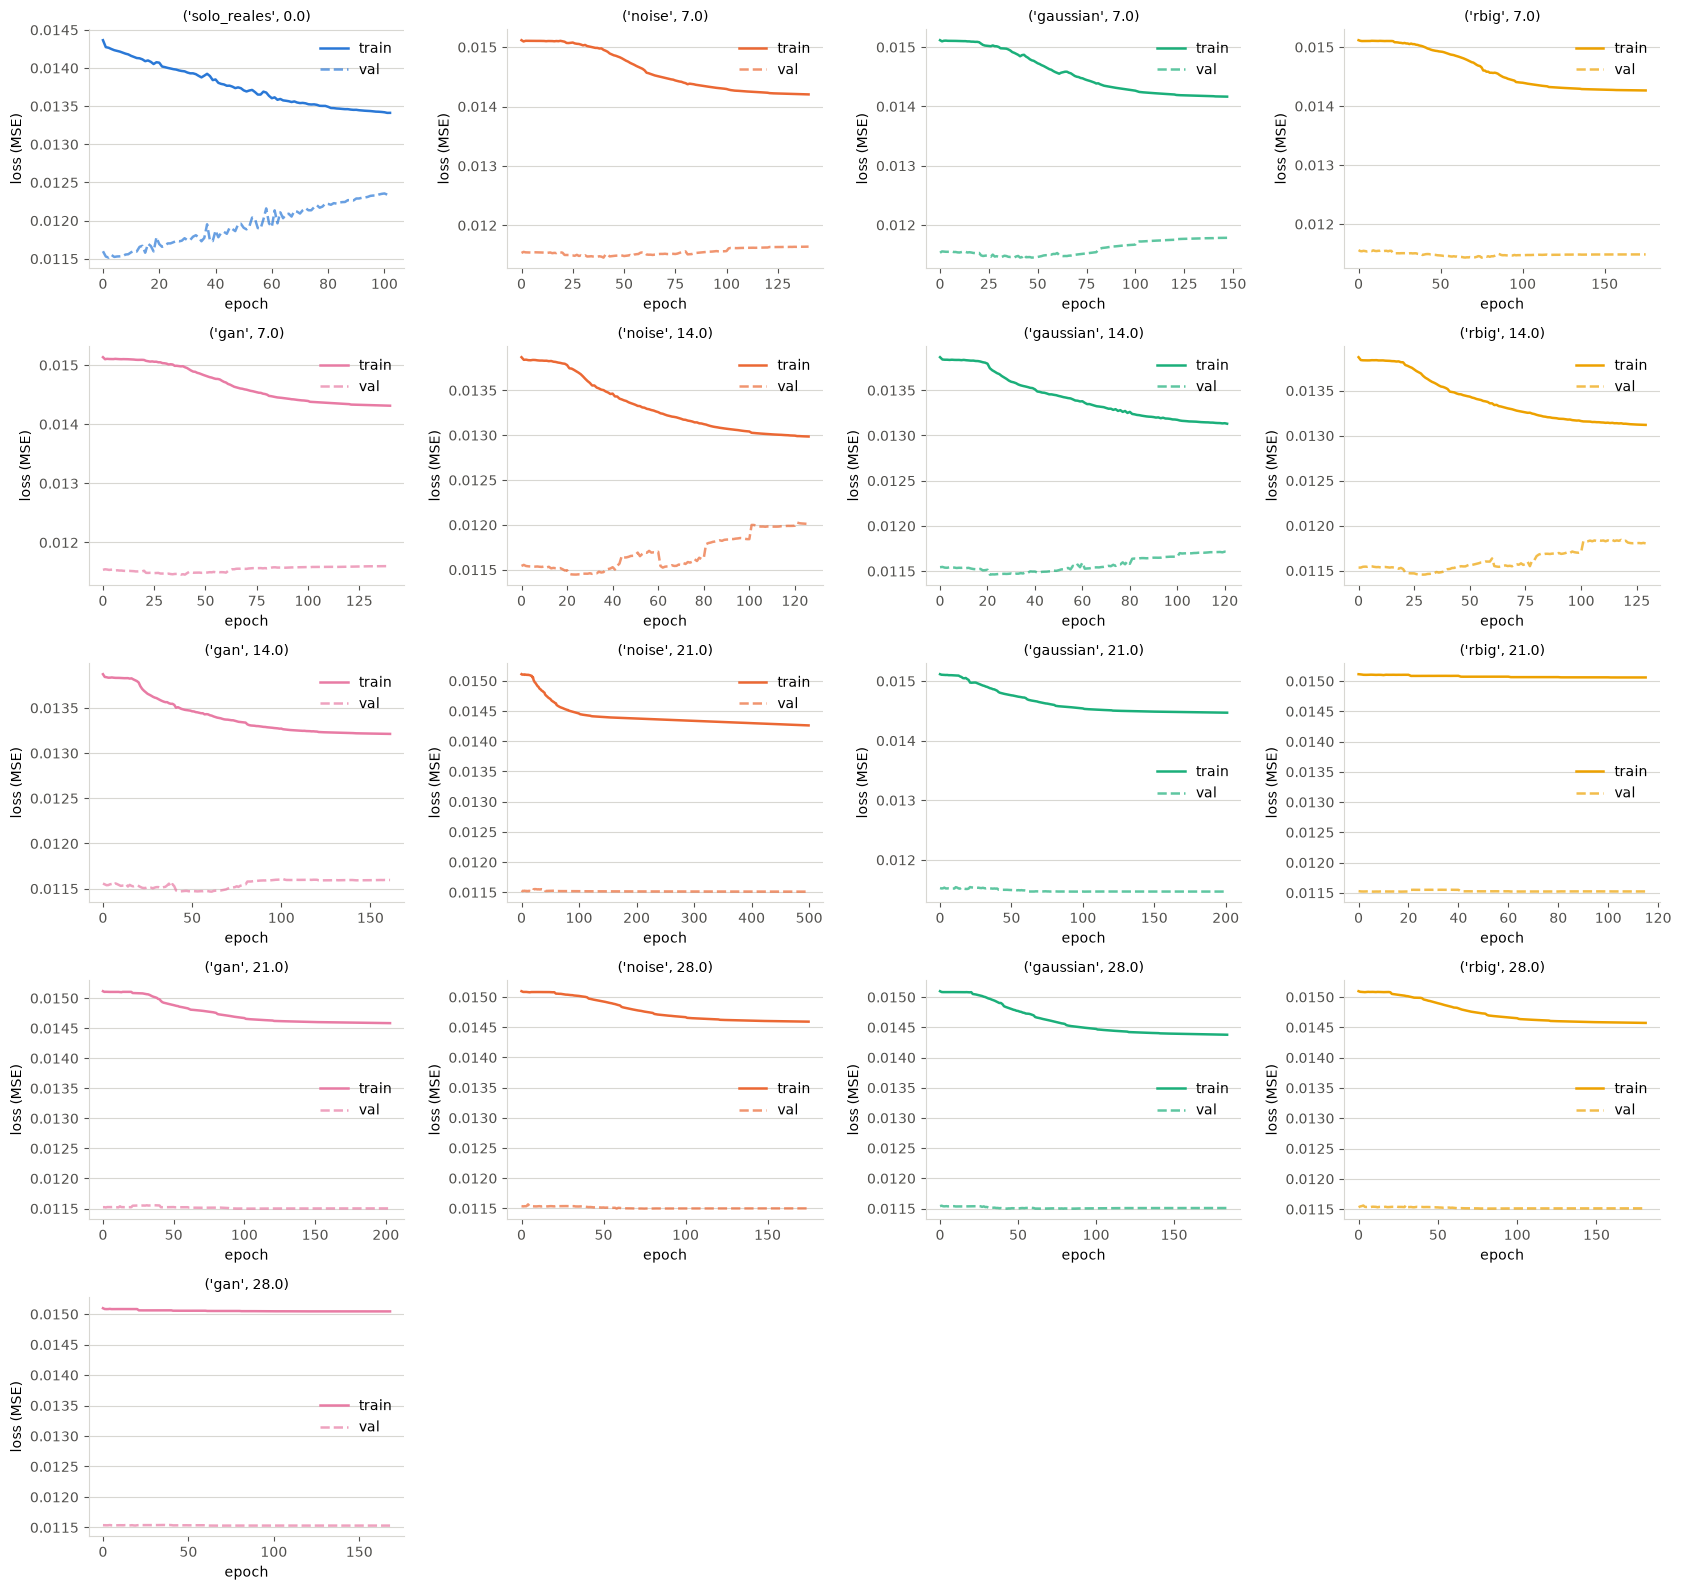

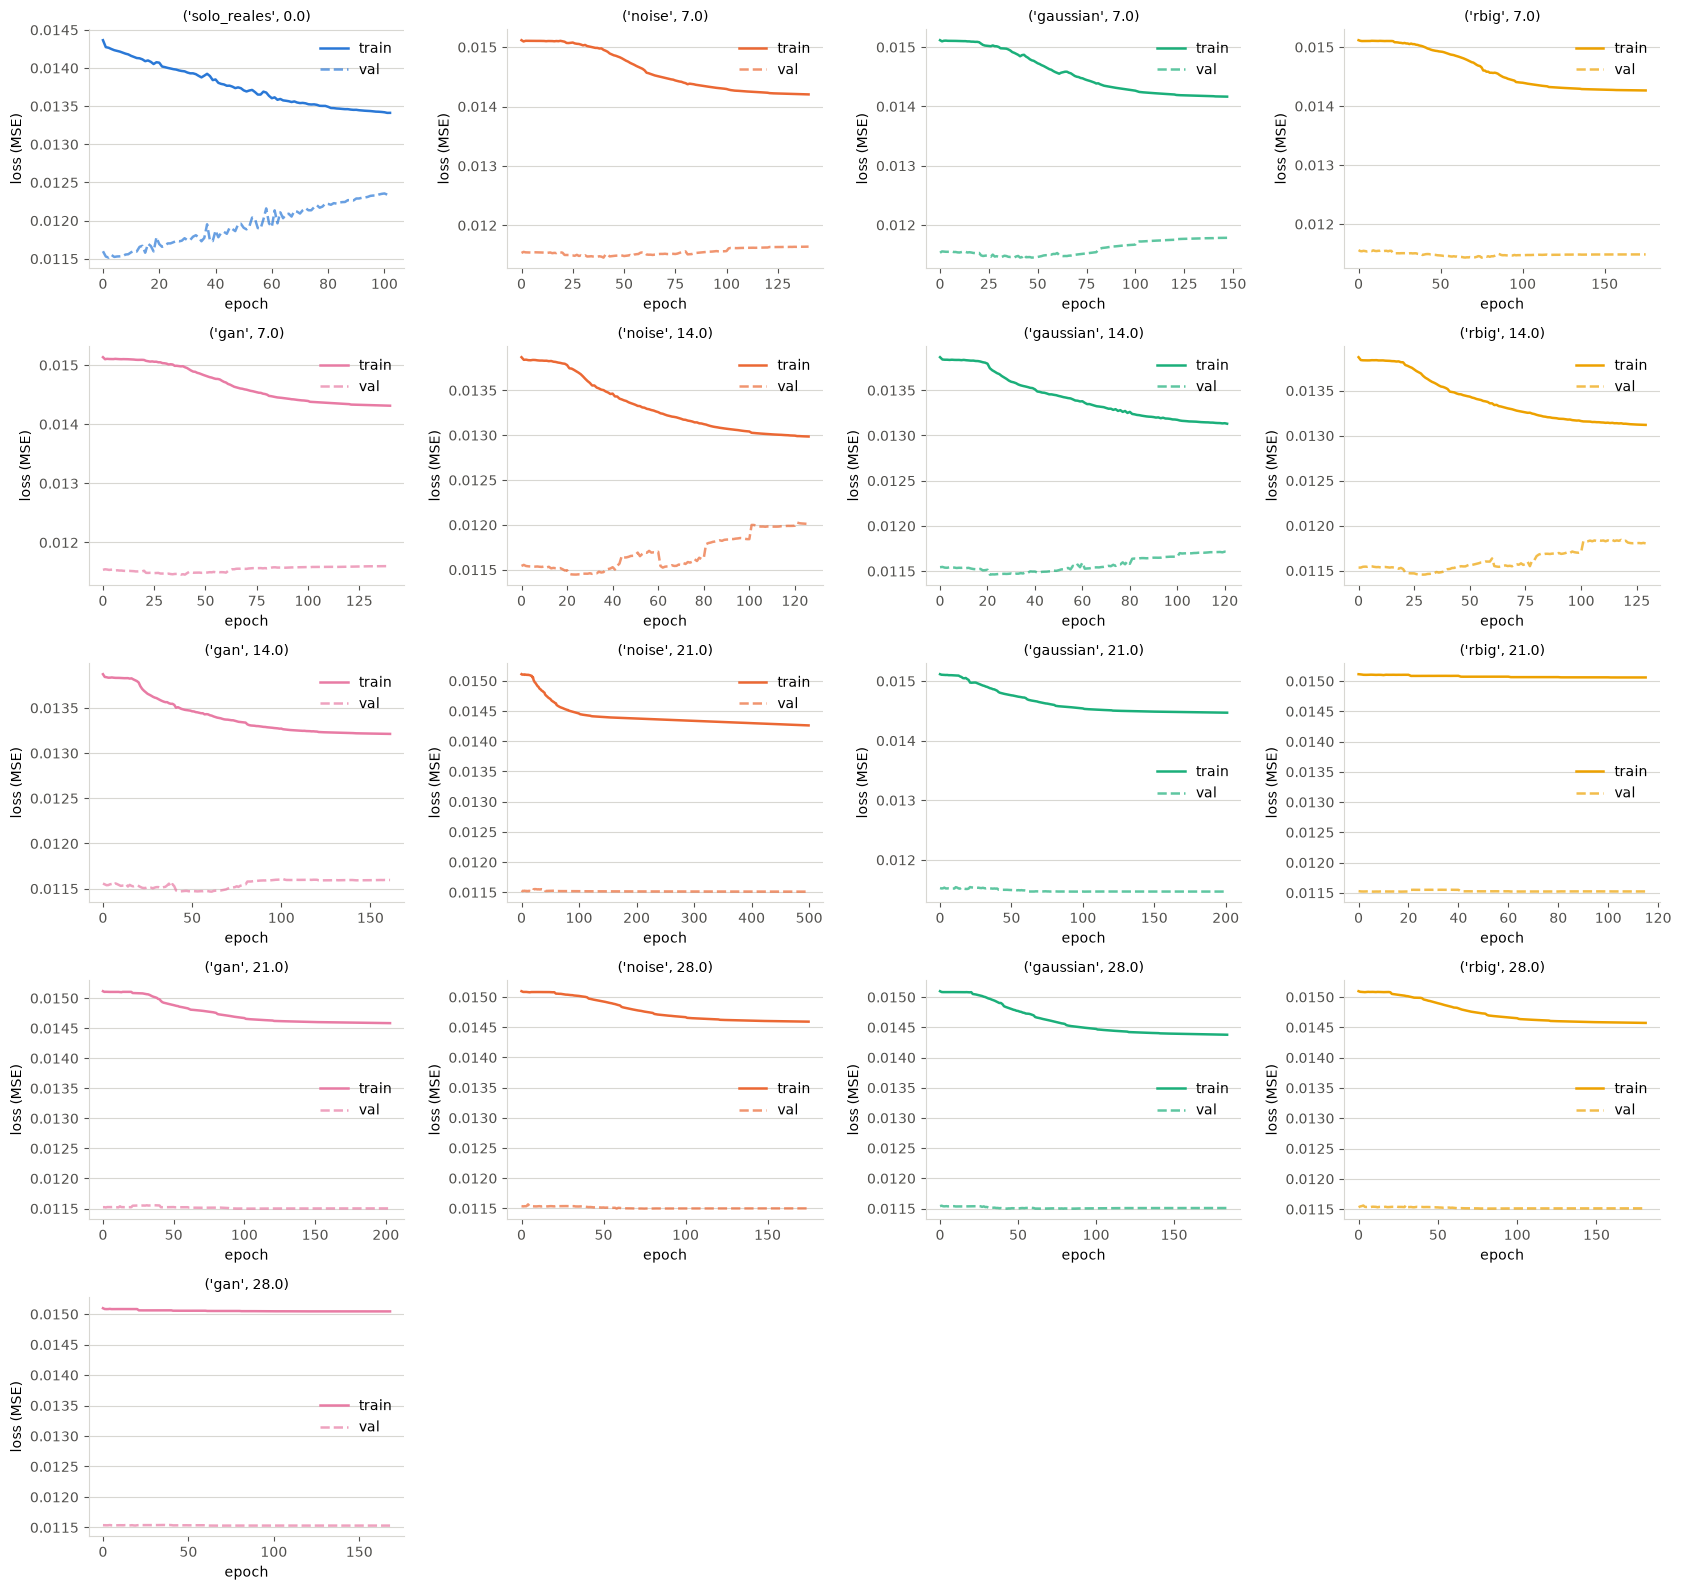

In [14]:
fig = pl.plot_loss_grid(histories, ncols=4)
pl.savefig(fig, "04_loss_curvas_rejilla")
fig

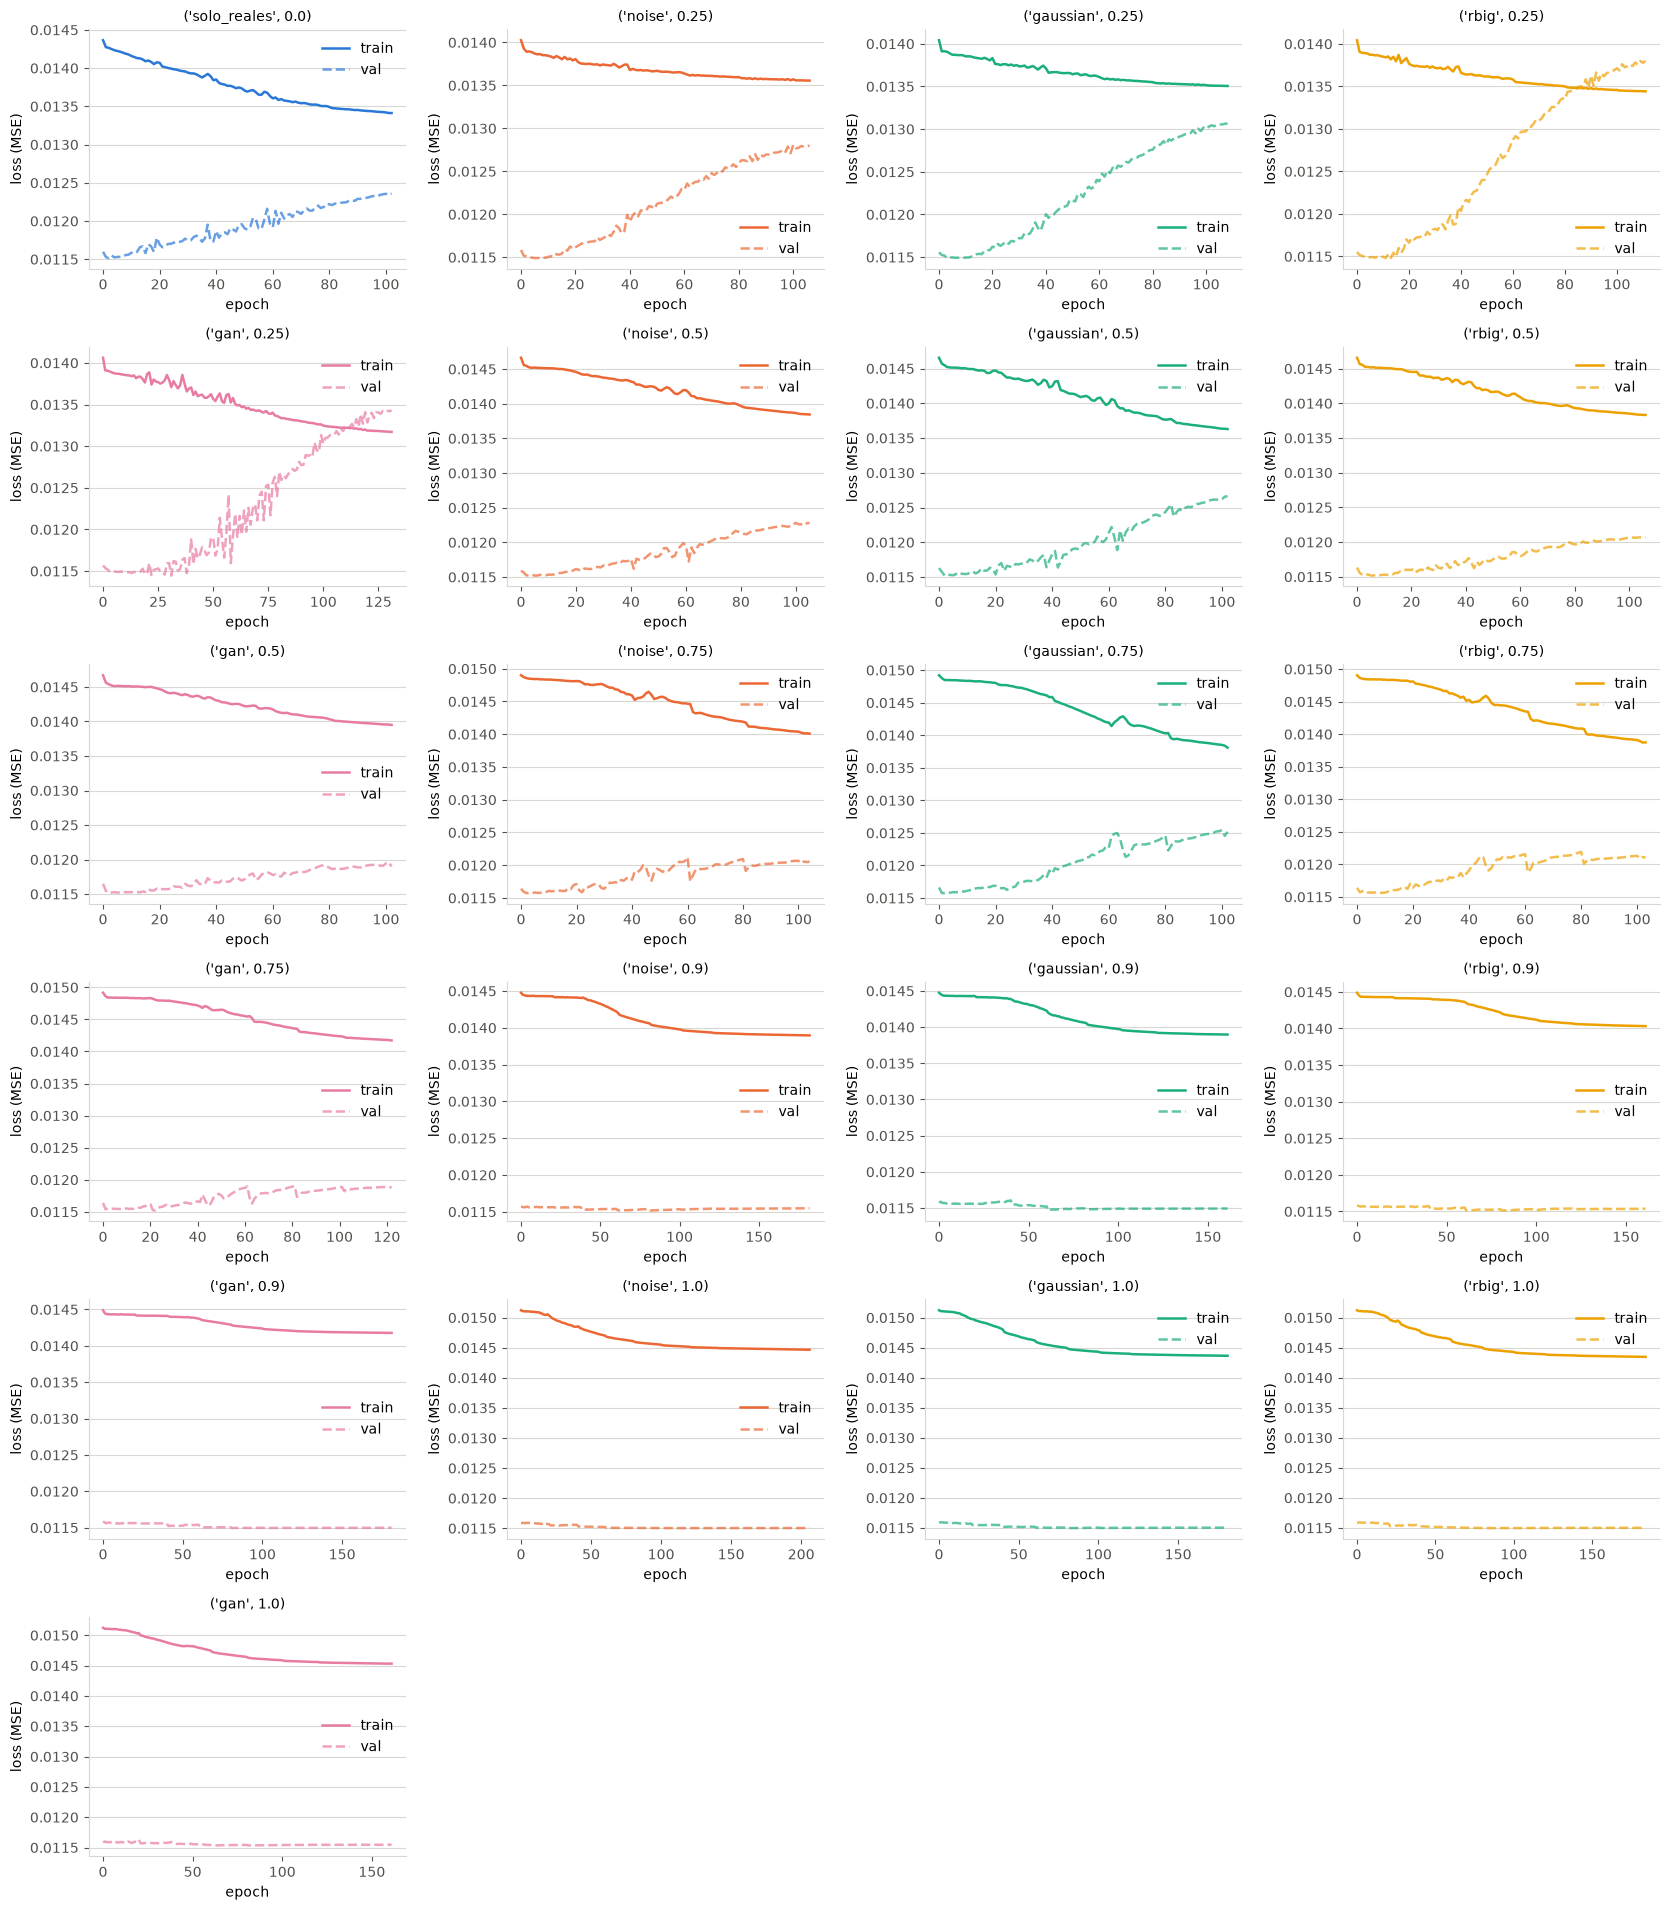

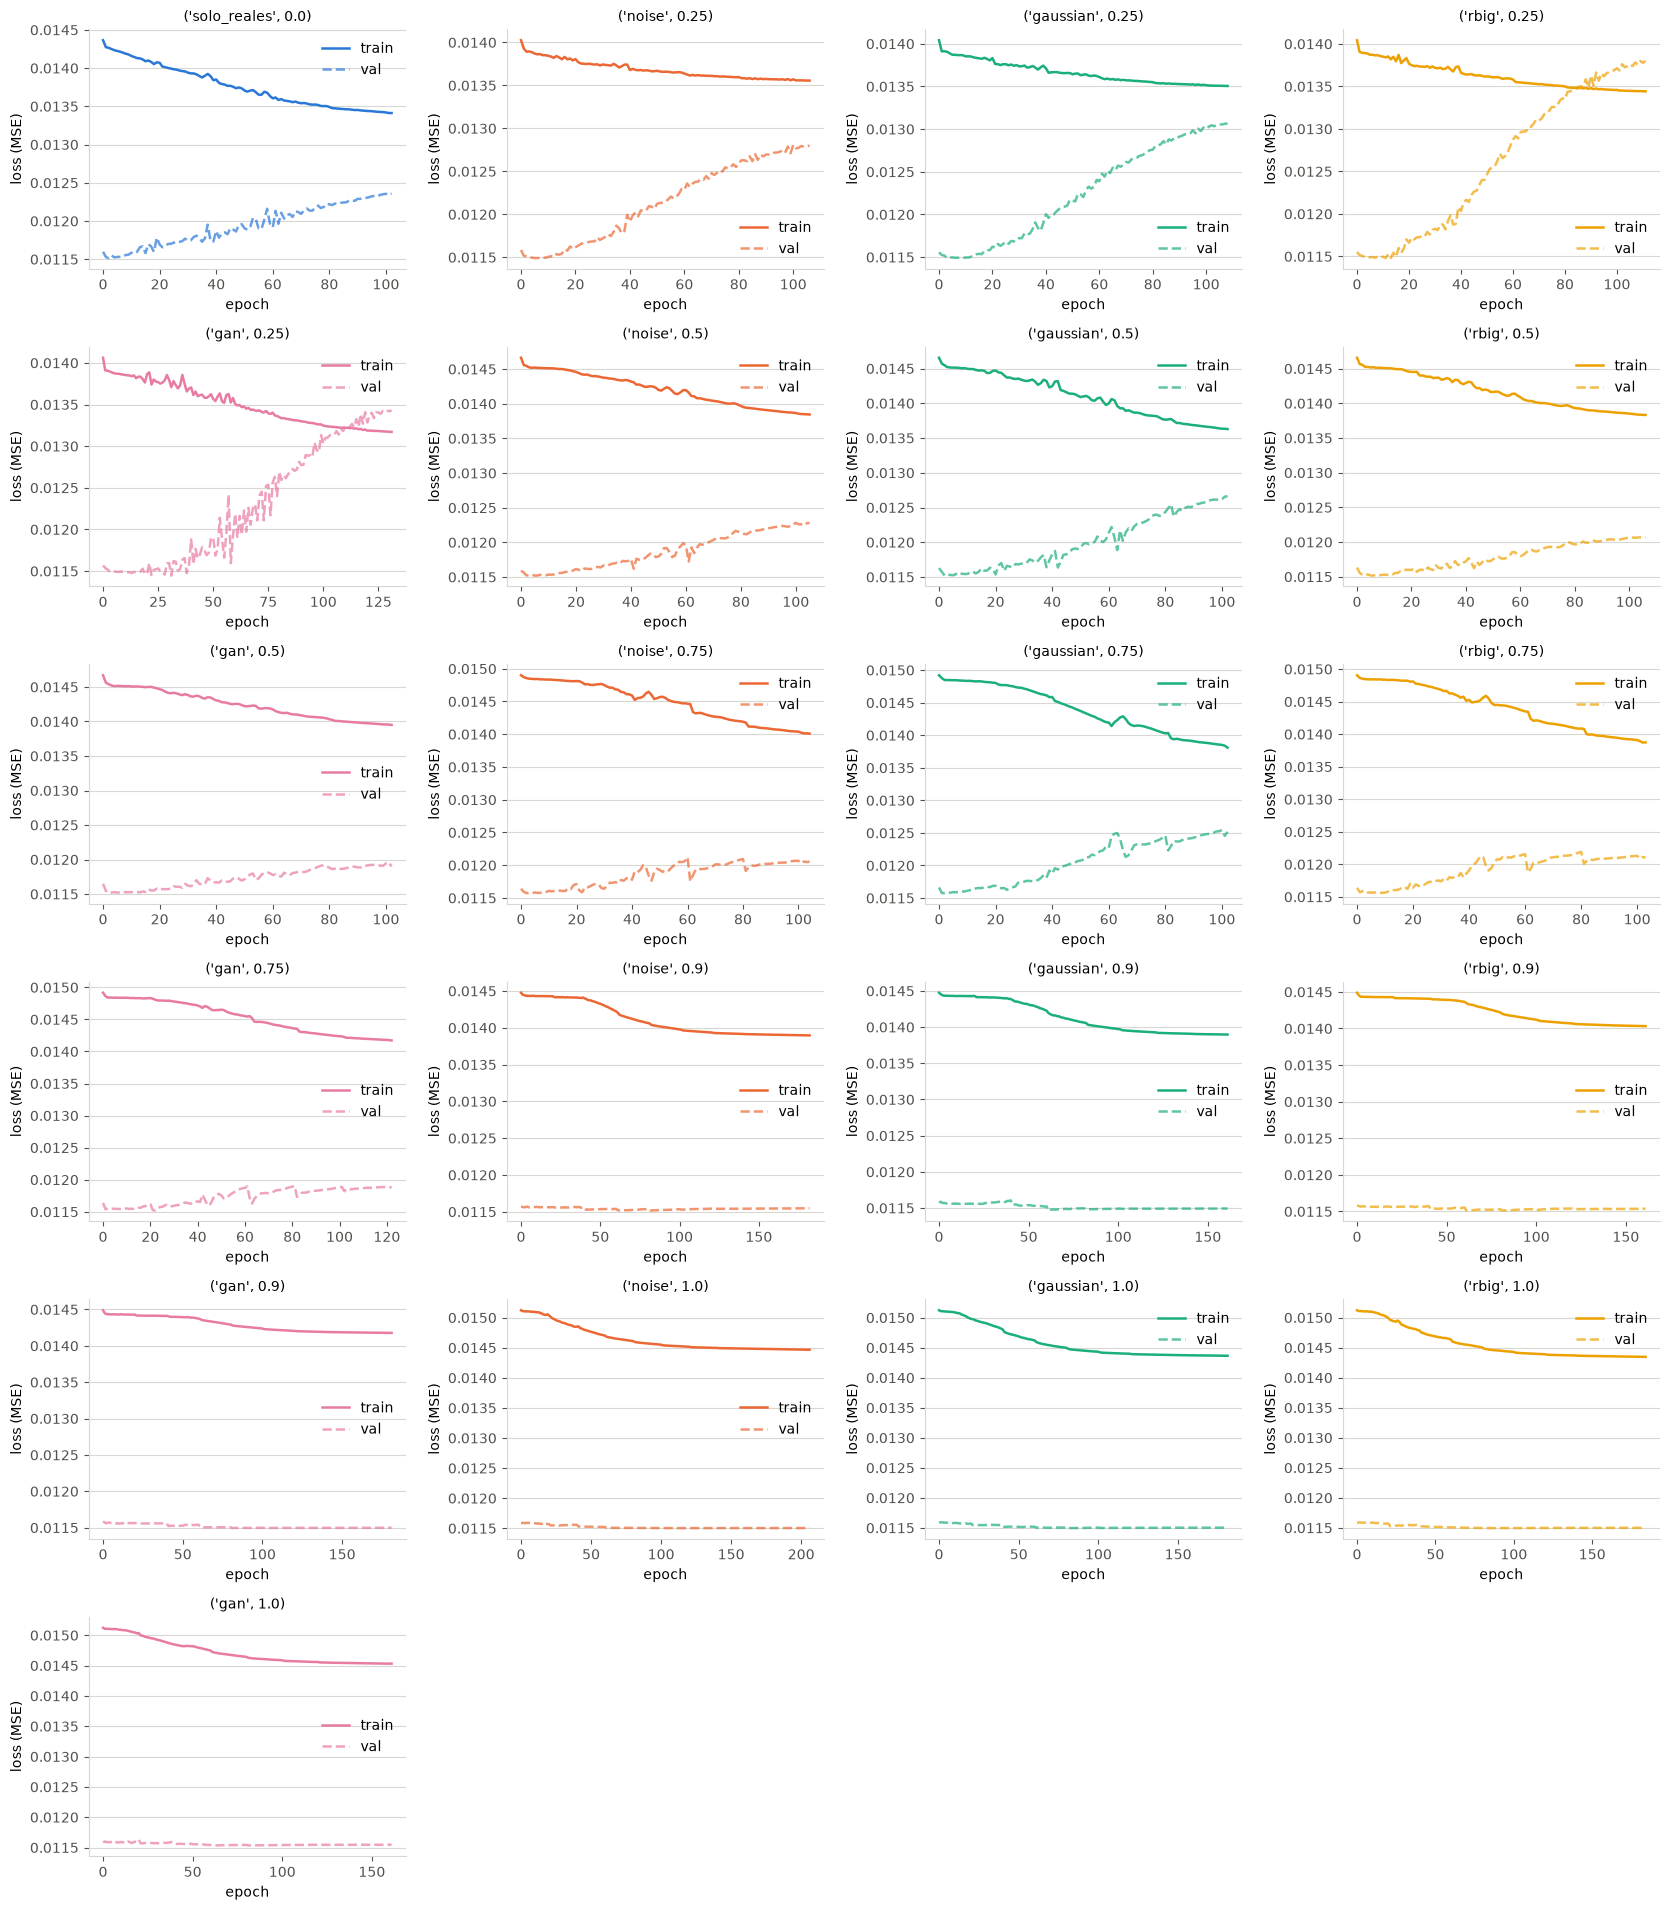

In [15]:
fig = pl.plot_loss_grid(histories_pct, ncols=4)
pl.savefig(fig, "04_loss_curvas_porcentaje")
fig

## 8. Guardar resultados consolidados (`datos/interim/`, gitignored)

El notebook 05 solo lee estos CSV/tablas — no vuelve a entrenar nada.

In [16]:
results.to_pickle(config.INTERIM_DIR / "resultados_finales.pkl")
results_pct.to_pickle(config.INTERIM_DIR / "resultados_porcentaje.pkl")
per_ticker_table.to_pickle(config.INTERIM_DIR / "resultados_por_banco.pkl")
print("Listo. Tablas en reports/tables/04_resultados_rejilla_profundidad.csv"
      " y 04_resultados_rejilla_porcentaje.csv")

Listo. Tablas en reports/tables/04_resultados_rejilla_profundidad.csv y 04_resultados_rejilla_porcentaje.csv
